In [1]:
from pathlib import Path
import re
import pandas as pd

data_dir = Path("../data/raw/survey_data_2010_2024").resolve()
if not data_dir.exists():
    raise FileNotFoundError(
        f"Directory not found: {data_dir}\n"
        f"Current working directory: {Path.cwd()}"
    )

# Paste ZIP codes here as comma-separated values. Keep as strings to preserve leading zeros.
zip_codes_raw = """
11220,11232,11209,11231,11219,07305,10301,11228,07002,11252,11215,11218,10310,11245,11204,10041,10004,10304,11217,11241,11242,11202,10043,10305,11201,10006,10270,10005,10280,10271,10045,11243,07304,10277,10281,10038,10080,10008,11214,10313,10279,07311,07302,11238,10007,10090,10282,11226,10108,10117,10124,10125,10126,10129,10130,10131,10132,10133,10138,10156,10157,10159,10160,10163,10164,10185,10203,10211,10212,10213,10256,10258,10259,10260,10261,10265,10268,10269,10272,10273,10274,10275,10285,10286,11230,10278,10302,10013,11225,11205,07310,11251,07308,07303,07399,10002,07395,11223,11216,10012,11210,07201,11249,11213,10014,11203,07306,11224,10009,10276,10003,07030,10303,11206,10113,10249,10011,11211,11229,10242,10110,10010,07307,07114,10060,11233,11221,11212,07099,07105,07097,10314,07206,10118,10116,10001,10199,10016,10306,10121,10120,10119,11235,10122,10123,10311,11222,10018,11237,10158,11247,10178,10168,10165,07032,10174,11234,10166,10170,10173,11236,07087,10102,11109,10109,10114,10017,10175,10036,10169,10176,10167,10177,10179,10081,10087,10172,10171,11207,07086,10112,11120,10111,10020,10055,07029,10154,10152,10103,10101,10104,10150,10022,10019,07175,10105,10106,10107,07207,10151,10153,10155,07101,07184,07188,07189,07191,07192,07193,07195,07198,07199,07102,07094,11101,10308,07202,11378,10065,10044,10023,11239,11104,10069,07108,10021,07112,11385,07208,11208,07093,10162,10075,07103,07096,11106,10024,11256,10028,07047,11379,11377,07205,11697,07104,07071,07031,10128,10312,11102,11103,11421,11695,11416,07107,11414,07036,11417,11373,07111,07008,11374,10025,11372,10029,07203,07106,07109,11370,11105,07019,07018,07204,10026,10035,07022,07017,11694,07073,10115,07083,11418,11375,07010,11369,11415,11419,10027,11420,07072,11693,10309,11368,07070,07657,07020,11424,10037,07065,07001,11371,10454,07064,07051,10030,11367,07077,07050,07079,07033,07074,07040,07088,11435,07110,07003,11405,11425,11499,10031,07643,07014,10451,11436,11431,10455,10039,07016,07028,10474,10032,11351,07650,11355,11430,11451,11692,07075,07660,07608,11352,11354,07042,07041,11433,11432,11356,07024,07057,11439,10456,10307,07066,07699,10452,11386,07027,11434,10459,07095,11366,07604,07067,11365,07055,07012,07052,07605,11437,10473,08861,07081,11380,08830,07734,11690,08862,11358,10033,11412,07603,11691,07015,10040,11423,10457,11357,10472,10453,07043,07090,11096,07644,07758,11413,07091,07026,10460,08863,07078,07044,07602,07601,07718,11422,07011,10034,07666,07092,11361,11427,07013,10462,11411,11364,11360,11429,07735,07076,11428,07632,07737,07631,10468,07021,07901,07009,07999,07902,08832,10458,11516,10461,11359,07730,07607,10463,11509,10465,07039,07662,08840,08879,08820,11559,07752,07007,07716,07663,11581,07732,11598,07503,07023,07407,11582,07721,07068,11426,11362,11363,10467,07748,11580,07424,11003,07513,08837,10469,07504,11557,11001,11002,07006,07062,10471,11022,11004,07621,07670,07061,07974,07661,07501,11005,08859,10475,10464,07928,10470,11021,07799,11023,07509,07510,07511,07533,07543,07544,07646,07505,11020,07514,07512,07922,07760,10466,08818,11042,11563,07747,11024,11565,07502,07522,11010,07410,07080,10705,11518,07060,07524,07652,07653,07004,07733,07932,11040,07936,07704,07626,07628,08817,07701,07069,10702,10550,07940,07538,08872,11558,07649,07063,10704,10551,11552,07507,08871,08855,11030,10553,07058,07627,07641,11570,10803,11571,08899,11572,07452,11531,11561,07506,07935,10805,07739,07738,07508,10552,07630,07620,11530,07474,07750,07961,07624,11507,11501,10701,08882,11596,11050,07933,08904,07702,10802,11550,07470,07451,11551,10708,07981,10801,10703,07450,08854,07703,08812,07751,07676,07035,07976,11577,07054,11576,08857,07980,07034,07757,07765,08901,07640,11549,11514,08906,07946,11599,07423,07440,11569,11555,10710,07648,07432,08903,08933,08989,11553,08846,11575,07927,10709,10707,11520,07059,07642,08816,07082,07045,11547,07481,10804,11548,07675,07962,07963,10538,11556,07724,07740,11579,07960,10706,07647,08850,07764,07463,08884,11590,10964,07444,11568,07746,11566,07677,07722,11554,07417,08880,08805,10543,10983,07046,07656,10522,07401,07950,07939,10976,08836,10583,11545,11710,10502,07755,11542,07920,07878,07442,08902,08873,07457,07458,10503,08828,07005,07436,10968,07938,07645,07723,10962,07834,10530,07712,11753,11793,11756,10965,11853,10528,11560,11802,10533,11801,07446,07711,08890,07405,07924,07926,10606,10913,11783,07420,10580,11815,10605,10607,08835,08831,07970,08875,07763,07945,07465,11714,10601,08807,07430,11765,07753,10602,10610,11758,07756,10523,08810,10954,10960,07726,07869,07801,11791,11775,07978,08824,08823,10994,11709,11773,07754,07720,07802,11771,07866,10603,11803,10591,08869,07842,11762,10577,10982,08852,07495,07977,10977,07717,11804,07728,07710,11737,07727,10573,10952,07806,11797,10604,07845,11735,07715,07803,10595,10989,10532,10931,07921,11701,07934,10901,07719,08876,06836,07456,07931,07885,07847,08512,11724,11726,07480,07930,08821,07762,07876,06830,10956,11747,10594,08844,08502,08528,10570,08720,07731,11757,10974,10920,10510,08553,07856,06831,07979,08536,07852,08750,06878,11704,08858,08535,07438,06870,11798,10545,07849,11743,11702,08888,08870,07850,07836,08730,07857,08558,08510,11707,08542,10923,11703,08504,06904,06911,06912,06913,06914,06926,06927,10984,08541,08543,08544,06901,08724,06902,10562,07421,10514,11729,10993,11740,11721,10979,10520,07460,08550,08742,08561,08887,11795,10987,07830,10546,06905,07874,06906,07828,08833,07871,07853,10925,10975,10521,11731,08701,07439,10980,08691,10548,06907,07870,08527,11718,10549,11768,06903,11706,08526,06820,10596,08885,08723,11725,08525,07422,10511,07416,11717,07821,10506,06853,07840,08514,08690,10910,10986,08738,08648,10912,07462,10507,08551,07428,07820,08822,07419,11751,10566,08501,08801,06854,08829,10959,10567,08619,10990,07879,11754,08739,10926,08826,10911,08534,06840,11788,11722,07848,10517,06850,07865,10598,08755,10576,06855,08533,08809,08733,07839,11752,11787,11730,08638,06852,06856,06857,06858,06860,07418,10928,10536,08735,08620,07880,08753,10950,08629,10547,08601,08602,08603,08604,08605,08606,08607,08645,08646,08647,08666,08695,08610,06851,08618,07822,10981,08515,08650,10537,10588,08608,07838,11780,08625,10518,10527,11769,08757,08628,08827,07860,08560,07846,10921,08751,08867,08530,10587,10526,10535,08611,08754,08756,11716,10930,08557,11767,10590,10589,07863,10918,06881,06888,06889,08732,10540,10969,10578,06880,06897,11796,08511,11779
"""

target_zips = {
    z.strip().zfill(5)
    for z in zip_codes_raw.replace("\n", ",").split(",")
    if z.strip()
}

# Pattern: subset_YYYYW (year/wave used only to identify file groups)
name_pattern = re.compile(r"^(catch|trip|size)_(\d{4})(\d)$", flags=re.IGNORECASE)

def read_file(path: Path) -> pd.DataFrame:
    ext = path.suffix.lower()
    if ext == ".csv":
        return pd.read_csv(path, low_memory=False)
    if ext in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if ext == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported file type: {path.name}")

def normalize_id(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0+$", "", regex=True)
    )

def normalize_zip(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0+$", "", regex=True)
        .str.zfill(5)
    )

def first_non_null(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if not s.empty else pd.NA

def collapse_to_one_row_per_id(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    if "ID_CODE" not in df.columns:
        return pd.DataFrame(columns=["ID_CODE"])
    df = df.dropna(subset=["ID_CODE"]).copy()
    return df.groupby("ID_CODE", as_index=False).agg(first_non_null)

valid_files = []
for path in sorted(data_dir.iterdir()):
    if not path.is_file():
        continue
    match = name_pattern.match(path.stem)
    if not match:
        continue
    subset = match.group(1).lower()
    valid_files.append((path, subset))

# --- STEP 1: Load and filter TRIP data by ZIP codes ---
trip_parts = []
for path, subset in valid_files:
    if subset != "trip":
        continue
    df = read_file(path)
    if "ID_CODE" not in df.columns or "ZIP" not in df.columns:
        continue
    df["ID_CODE"] = normalize_id(df["ID_CODE"])
    df["ZIP"] = normalize_zip(df["ZIP"])
    df = df[df["ZIP"].isin(target_zips)].copy()
    if not df.empty:
        trip_parts.append(df)

if not trip_parts:
    raise ValueError("No trip rows matched your ZIP list. Check ZIP values and formats.")

trip_all = pd.concat(trip_parts, ignore_index=True, sort=False)
allowed_id_codes = set(trip_all["ID_CODE"].dropna().unique())

# --- STEP 2: Load CATCH and SIZE data filtered by allowed ID_CODEs ---
catch_parts = []
size_parts = []
for path, subset in valid_files:
    if subset not in {"catch", "size"}:
        continue
    df = read_file(path)
    if "ID_CODE" not in df.columns:
        continue
    df["ID_CODE"] = normalize_id(df["ID_CODE"])
    df = df[df["ID_CODE"].isin(allowed_id_codes)].copy()
    if df.empty:
        continue
    if subset == "catch":
        catch_parts.append(df)
    else:
        size_parts.append(df)

catch_all = pd.concat(catch_parts, ignore_index=True, sort=False) if catch_parts else pd.DataFrame(columns=["ID_CODE"])
size_all = pd.concat(size_parts, ignore_index=True, sort=False) if size_parts else pd.DataFrame(columns=["ID_CODE"])

# --- STEP 3: Collapse trip and size to one row per ID_CODE ---
trip_one = collapse_to_one_row_per_id(trip_all)
size_one = collapse_to_one_row_per_id(size_all)

# --- STEP 4: PIVOT catch data - species become columns, TOT_CAT becomes values ---
# Only include species that were caught when DIST was 1 or 8
# First, get ID_CODEs from trips where DIST is 1 or 8
dist_filter_ids = set(
    trip_all.loc[trip_all["DIST"].isin([1, 8]), "ID_CODE"].dropna().unique()
)

# Filter catch data to only include rows from surveys with DIST 1 or 8
catch_filtered = catch_all[catch_all["ID_CODE"].isin(dist_filter_ids)].copy()

# Each ID_CODE gets one row; each species caught becomes a column with TOT_CAT value
if not catch_filtered.empty and "COMMON" in catch_filtered.columns and "TOT_CAT" in catch_filtered.columns:
    catch_pivoted = catch_filtered.pivot_table(
        index="ID_CODE",
        columns="COMMON",       # Species name becomes column headers
        values="TOT_CAT",       # Total catch for that species
        aggfunc="sum",          # Sum if same species appears twice (edge case)
        fill_value=0            # 0 if species not caught in that survey
    ).reset_index()

    # Flatten column names (pivot_table creates MultiIndex)
    catch_pivoted.columns.name = None
else:
    catch_pivoted = pd.DataFrame(columns=["ID_CODE"])

# --- STEP 5: Join tables ---
df_survey = trip_one.merge(catch_pivoted, on="ID_CODE", how="left")
df_survey = df_survey.merge(size_one, on="ID_CODE", how="left", suffixes=("", "_size"))

# Fill NaN for species columns (ID_CODEs with no catch data at all)
species_cols = [c for c in catch_pivoted.columns if c != "ID_CODE"]
if species_cols:
    df_survey[species_cols] = df_survey[species_cols].fillna(0)

# --- Validation ---
assert df_survey["ID_CODE"].nunique() == len(df_survey), "Duplicate ID_CODE rows detected!"

print(f"Using directory: {data_dir}")
print(f"Target ZIP count: {len(target_zips)}")
print(f"Trip rows kept after ZIP filter: {len(trip_all)}")
print(f"Unique ID_CODE kept: {len(allowed_id_codes)}")
print(f"Surveys with DIST 1 or 8: {len(dist_filter_ids)}")
print(f"Species columns created: {len(species_cols)}")
print(f"Final shape: {df_survey.shape}")
df_survey.head()

Using directory: C:\Users\ross9\GitHub\fishing-predictor\data\raw\survey_data_2010_2024
Target ZIP count: 1061
Trip rows kept after ZIP filter: 77916
Unique ID_CODE kept: 71423
Surveys with DIST 1 or 8: 61034
Species columns created: 286
Final shape: (71423, 392)


,ID_CODE,PRIM2_COMMON,PRIM1_COMMON,STRAT_ID,PSU_ID,YEAR,REG_RES,ST_RES,CNTY_RES,ST,...,WGT_UNADJ,WP_SIZE,L_IN_BIN,L_CM_BIN,VAR_ID_size,ARX_METHOD_size,ALT_FLAG_size,DATE_PUBLISHED_size,MONTH_size,IMP_REC_size
0,1000920140505017,<NA>,<NA>,2014051235wdS:8AM-8PM,2014312351000920140505,2014,5.0,34.0,29.0,12,...,<NA>,336.393815,24.0,62.0,2014051235wdS:8AM-8PM,<NA>,0.0,03/03/2025,<NA>,<NA>
1,1000920140505018,<NA>,<NA>,2014051235wdS:8AM-8PM,2014312351000920140505,2014,5.0,34.0,29.0,12,...,<NA>,336.393815,<NA>,<NA>,2014051235wdS:8AM-8PM,<NA>,0.0,03/03/2025,<NA>,<NA>
2,1000920150620006,<NA>,<NA>,2015061237weS:8AM-8PM,2015312371000920150620,2015,5.0,36.0,59.0,12,...,<NA>,1161.249729,<NA>,<NA>,2015061237weS:8AM-8PM,<NA>,0.0,03/03/2025,<NA>,<NA>
3,1000920150627020,<NA>,RED GROUPER,2015061237weS:8AM-8PM,2015312371000920150627,2015,5.0,34.0,29.0,12,...,<NA>,3589.398672,6.0,17.0,2015061237weS:8AM-8PM,<NA>,0.0,03/03/2025,<NA>,<NA>
4,1000920150711002,<NA>,COMMON SNOOK,2015071237weS:8AM-8PM,2015412371000920150711,2015,5.0,34.0,37.0,12,...,<NA>,1836.569119,<NA>,<NA>,2015071237weS:8AM-8PM,<NA>,0.0,03/03/2025,<NA>,<NA>


In [2]:
# Build survey timestamp from ID_CODE date (digits 6-13, YYYYMMDD) + TIME (HHMM), then round to nearest hour
id_for_ts = normalize_id(df_survey["ID_CODE"])
date_part = id_for_ts.str.slice(5, 13)

if "TIME" in df_survey.columns:
    time_numeric = pd.to_numeric(df_survey["TIME"], errors="coerce").round()
    time_part = time_numeric.astype("Int64").astype("string").str.zfill(4)
    df_survey["SURVEY_TIMESTAMP"] = pd.to_datetime(
        date_part + " " + time_part,
        format="%Y%m%d %H%M",
        errors="coerce",
    ).dt.round("h")
else:
    df_survey["SURVEY_TIMESTAMP"] = pd.NaT

# TIME is no longer needed once SURVEY_TIMESTAMP has been created
df_survey = df_survey.drop(columns=["TIME"], errors="ignore")

print("Created SURVEY_TIMESTAMP and dropped TIME.")
df_survey[["ID_CODE", "SURVEY_TIMESTAMP"]].head()

Created SURVEY_TIMESTAMP and dropped TIME.


C:\Users\ross9\AppData\Local\Temp\ipykernel_4016\1953086930.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_survey["SURVEY_TIMESTAMP"] = pd.to_datetime(


,ID_CODE,SURVEY_TIMESTAMP
0,1000920140505017,2014-05-05 17:00:00
1,1000920140505018,2014-05-05 17:00:00
2,1000920150620006,2015-06-20 16:00:00
3,1000920150627020,2015-06-27 17:00:00
4,1000920150711002,2015-07-11 11:00:00


In [3]:
pd.set_option("display.max_columns", None)

def print_summary(df: pd.DataFrame):
    df.head(100)
    print("Null counts per column:")
    print(df.isna().sum())

    print("\nData types and non-null counts:")
    print(df.info())

    print("\nSummary statistics for numeric columns:")
    print(df.describe())

print_summary(df_survey)

Null counts per column:
ID_CODE                    0
PRIM2_COMMON           48625
PRIM1_COMMON            9339
STRAT_ID                   0
PSU_ID                     0
                       ...  
ALT_FLAG_size           6263
DATE_PUBLISHED_size     6263
MONTH_size             21912
IMP_REC_size           65989
SURVEY_TIMESTAMP           0
Length: 392, dtype: int64

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71423 entries, 0 to 71422
Columns: 392 entries, ID_CODE to SURVEY_TIMESTAMP
dtypes: datetime64[ns](1), float64(316), int64(8), object(65), string(2)
memory usage: 213.6+ MB
None

Summary statistics for numeric columns:
               YEAR        ST_RES      CNTY_RES            ST          CNTY  \
count  71423.000000  71423.000000  71423.000000  71423.000000  71423.000000   
mean    2019.423869     34.476513     56.856489     33.720608     60.875054   
min     2014.000000      1.000000      1.000000      1.000000      1.000000   
25%     2017.

In [4]:
# Filter out species with fewer than 100 catches
MIN_CATCHES = 100

# Define known non-species columns
metadata_cols = {
    'ID_CODE', 'PRIM2_COMMON', 'PRIM1_COMMON', 'STRAT_ID', 'PSU_ID', 'YEAR',
    'REG_RES', 'ST_RES', 'CNTY_RES', 'ST', 'CNTY', 'INTSITE', 'MODE_F',
    'MODE_FX', 'AREA', 'AREA_X', 'HRSF', 'ADD_HRS', 'FFDAYS12', 'FFDAYS2',
    'CNTRBTRS', 'NUM_TYP2', 'NUM_TYP3', 'NUM_TYP4', 'NUM_TYP6', 'PARTY',
    'FIRST', 'SUB_REG', 'WAVE', 'CATCH', 'ON_LIST', 'NUM_TYP9', 'BOAT_HRS',
    'TELEFON', 'COASTAL', 'NEW_LIST', 'KOD', 'ASG_CODE', 'MODE_ASG',
    'PRT_CODE', 'CELLTYPE', 'REGION', 'STRAT_INTERVAL', 'MONTH', 'COUNTY',
    'TIME', 'TSN1', 'TSN2', 'DISTKEYS', 'GEAR', 'PVT_RES', 'SEP_FISH',
    'ADD_PH', 'F_BY_P', 'DATE1', 'DIST', 'PRIM1', 'PRIM2', 'AREA_NC',
    'MODE2001', 'MONITOR', 'TOURN', 'TURTLE', 'AGE', 'SEX', 'ART_REEF',
    'REEFCODE', 'MUNI_RES', 'MUNI_TRP', 'WP_INT', 'VAR_ID', 'ARX_METHOD',
    'ALT_FLAG', 'LEADER', 'FL_REG', 'FSHINSP_A', 'NUM_FISH_A', 'ZIP',
    'DATE_PUBLISHED', 'REEF', 'IMP_REC', 'TOT_CAT'
}

# Identify species columns (must be numeric and not metadata or _size columns)
species_cols = [
    col for col in df_survey.columns
    if col not in metadata_cols 
    and not col.endswith('_size')
    and pd.api.types.is_numeric_dtype(df_survey[col])
]

# Count catches per species and filter
species_catch_counts = {col: (df_survey[col] > 0).sum() for col in species_cols}
species_to_remove = [col for col, count in species_catch_counts.items() if count < MIN_CATCHES]
species_to_keep = [col for col, count in species_catch_counts.items() if count >= MIN_CATCHES]

print(f"Total species found: {len(species_cols)}")
print(f"Species below threshold (<{MIN_CATCHES} catches): {len(species_to_remove)}")
print(f"Species to keep: {len(species_to_keep)}")
print(f"\nRemoving: {species_to_remove}")
print(f"\nKeeping: {species_to_keep}")

# Drop low-frequency species
df_survey = df_survey.drop(columns=species_to_remove)

print(f"\nFinal shape: {df_survey.shape}")

Total species found: 289
Species below threshold (<100 catches): 245
Species to keep: 44

Removing: ['ACADIAN REDFISH', 'AFRICAN POMPANO', 'ALBACORE', 'ALEWIFE', 'ALMACO JACK', 'AMBERJACK GENUS', 'AMERICAN EEL', 'AMERICAN SAND LANCE', 'AMERICAN SHAD', 'ANCHOVY FAMILY', 'ANGELFISH FAMILY', 'ATLANTIC BONITO', 'ATLANTIC BUMPER', 'ATLANTIC CUTLASSFISH', 'ATLANTIC MOONFISH', 'ATLANTIC NEEDLEFISH', 'ATLANTIC SHARPNOSE SHARK', 'ATLANTIC SILVERSIDE', 'ATLANTIC SPADEFISH', 'ATLANTIC STINGRAY', 'ATLANTIC STURGEON', 'ATLANTIC TARPON', 'ATLANTIC THREAD HERRING', 'ATLANTIC TOMCOD', 'BANDED RUDDERFISH', 'BAR JACK', 'BARNDOOR SKATE', 'BERMUDA CHUB', 'BIGEYE SCAD', 'BLACK DRUM', 'BLACK GROUPER', 'BLACK MARGATE', 'BLACKFIN TUNA', 'BLACKNOSE SHARK', 'BLACKSPOT SERGEANT', 'BLACKTIP SHARK', 'BLUE CATFISH', 'BLUE RUNNER', 'BLUE SHARK', 'BLUEBACK HERRING', 'BLUEFIN TUNA', 'BLUESTRIPED GRUNT', 'BLUNTNOSE STINGRAY', 'BONEFISH', 'BONNETHEAD', 'BOXFISH GENUS', 'BROWN BULLHEAD', 'BROWN TROUT', 'BULL SHARK', 'BUL

In [5]:
# Count null-coded values in FFDAYS12 and FFDAYS2
ffdays12_nulls = df_survey['FFDAYS12'].isin([998, 999]).sum()
ffdays2_nulls = df_survey['FFDAYS2'].isin([98, 99]).sum()

print(f"FFDAYS12 null codes (998/999): {ffdays12_nulls}")
print(f"FFDAYS2 null codes (98/99): {ffdays2_nulls}")
print(f"\nColumn with more nulls: {'FFDAYS12' if ffdays12_nulls > ffdays2_nulls else 'FFDAYS2'}")

FFDAYS12 null codes (998/999): 917
FFDAYS2 null codes (98/99): 514

Column with more nulls: FFDAYS12


In [6]:
# Merge related species into genus-level columns

# 1. Skates -> SKATE GENUS
df_survey['SKATE GENUS'] += df_survey['LITTLE SKATE'] + df_survey['CLEARNOSE SKATE']
df_survey = df_survey.drop(columns=['LITTLE SKATE', 'CLEARNOSE SKATE'])

# 2. Searobins -> SEAROBIN GENUS
df_survey['SEAROBIN GENUS'] += df_survey['NORTHERN SEAROBIN'] + df_survey['STRIPED SEAROBIN']
df_survey = df_survey.drop(columns=['NORTHERN SEAROBIN', 'STRIPED SEAROBIN'])

# 3. Dogfish -> DOGFISH SHARK
df_survey['DOGFISH SHARK'] += df_survey['SMOOTH DOGFISH'] + df_survey['SPINY DOGFISH']
df_survey = df_survey.drop(columns=['SMOOTH DOGFISH', 'SPINY DOGFISH'])

# Update species_to_keep to reflect merged columns
merged_out = {'LITTLE SKATE', 'CLEARNOSE SKATE', 'NORTHERN SEAROBIN', 'STRIPED SEAROBIN', 'SMOOTH DOGFISH', 'SPINY DOGFISH'}
species_to_keep = [s for s in species_to_keep if s not in merged_out]

print(f"Columns after merge: {len(df_survey.columns)}")
print(f"Species to keep: {len(species_to_keep)}")

Columns after merge: 141
Species to keep: 38


In [7]:
#dropping the columns I know I won't need
metadata_cols_to_keep = [ "ID_CODE", "SURVEY_TIMESTAMP", "FFDAYS2", "HRSF", "KOD", "MODE_F", "CNTRBTRS", "IMP_REC"]

df_survey = df_survey[metadata_cols_to_keep + species_to_keep] 
print(df_survey.head(100))
for col in df_survey.columns:
    print(col)

             ID_CODE    SURVEY_TIMESTAMP  FFDAYS2 HRSF KOD  MODE_F  CNTRBTRS  \
0   1000920140505017 2014-05-05 17:00:00      0.0  6.0  wd     7.0       1.0   
1   1000920140505018 2014-05-05 17:00:00      0.0  6.0  wd     7.0       1.0   
2   1000920150620006 2015-06-20 16:00:00      0.0  4.5  we     8.0       1.0   
3   1000920150627020 2015-06-27 17:00:00      3.0  7.0  we     8.0       0.0   
4   1000920150711002 2015-07-11 11:00:00      1.0  2.0  we     8.0       1.0   
..               ...                 ...      ...  ...  ..     ...       ...   
95  1104820141107005 2014-11-07 14:00:00      0.0  3.5  we     7.0       3.0   
96  1104820150812020 2015-08-12 17:00:00      0.0  3.0  wd     7.0       2.0   
97  1104820150812021 2015-08-12 17:00:00     98.0  3.0  wd     7.0       0.0   
98  1104920150811001 2015-08-11 13:00:00      0.0  3.0  wd     5.0       1.0   
99  1104920150811002 2015-08-11 13:00:00      0.0  3.0  wd     5.0       1.0   

   IMP_REC  ATLANTIC COD  ATLANTIC CROA

Missing columns (skipped): ['AREA_X', 'DIST', 'F_BY_P', 'MODE_FX', 'MODE2001', 'GEAR', 'FFDAYS12']


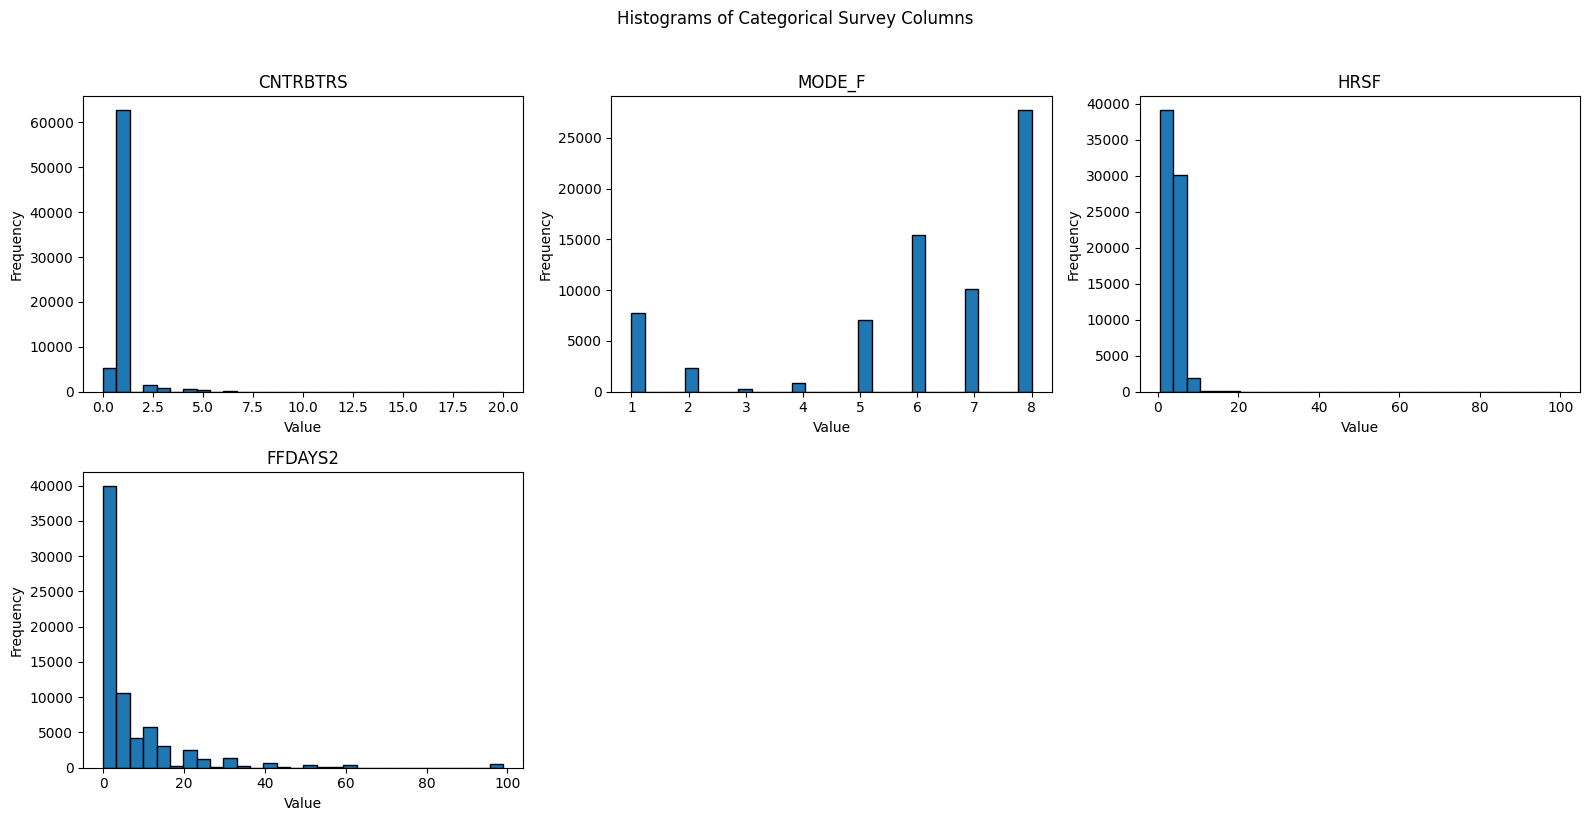

In [8]:
import math
import matplotlib.pyplot as plt
import pandas as pd

hist_cols = [
    "AREA_X",
    "DIST",
    "F_BY_P",
    "CNTRBTRS",
    "MODE_F",
    "MODE_FX",
    "MODE2001",
    "GEAR",
    "HRSF",
    "FFDAYS12",
    "FFDAYS2",
]

missing_cols = [c for c in hist_cols if c not in df_survey.columns]
if missing_cols:
    print("Missing columns (skipped):", missing_cols)

plot_cols = [c for c in hist_cols if c in df_survey.columns]
if not plot_cols:
    raise ValueError("None of the requested histogram columns exist in df_survey")

plot_df = df_survey[plot_cols].copy()
for c in plot_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)

axes = plot_df.hist(
    bins=30,
    figsize=(16, 4 * n_rows),
    layout=(n_rows, n_cols),
    edgecolor="black",
    grid=False,
 )

for ax in axes.flatten():
    if ax is not None:
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

plt.suptitle("Histograms of Categorical Survey Columns", y=1.02)
plt.tight_layout()
plt.show()

## Takeaways for Categorical Features

- **Gear** is negligible — almost all participants were fishing with hook on line.
- **Hours fished** does contains negligable amount of unknowns (value of 99). Unknowns can be imputed or dropped.
- Need to decide between:
  - **Exact mode** (specifying the type of shore structure), or
  - **Collapsed mode** (grouped categories)  
  Exact mode may lead to overfitting but could provide more detailed insight into fishing methods.
- Uncertainty about whether to average catch based on **contributors** to total catch.
- Unsure if **area** and **distance** variables may be collinear.
- **Fish by person** may be irrelevant.

In [9]:
# Drop rows where HRSF unknown
df_survey['HRSF'] = pd.to_numeric(df_survey['HRSF'], errors='coerce')
rows_before = len(df_survey)
df_survey = df_survey[df_survey['HRSF'] <= 40]
rows_after = len(df_survey)
print(f"Dropped {rows_before - rows_after} rows where HRSF > 40")
print(f"Remaining rows: {rows_after}")

Dropped 53 rows where HRSF > 40
Remaining rows: 71370


In [10]:
# Drop rows where FFDAYS2 unknown
df_survey['FFDAYS2'] = pd.to_numeric(df_survey['FFDAYS2'], errors='coerce')
rows_before = len(df_survey)
df_survey = df_survey[df_survey['FFDAYS2'] <= 70]
rows_after = len(df_survey)
print(f"Dropped {rows_before - rows_after} rows where FFDAYS2 > 70  ")
print(f"Remaining rows: {rows_after}")

Dropped 507 rows where FFDAYS2 > 70  
Remaining rows: 70863


In [11]:
#dropping more unnecessary columns
df_survey = df_survey.drop(columns=['LNGTH_IMP', 'WGT_IMP', 'WP_SIZE'])

In [12]:
# Fill missing IMP_REC with 0 
df_survey['IMP_REC'] = df_survey['IMP_REC'].fillna(0)
print(df_survey['IMP_REC'].value_counts())

IMP_REC
0.0    65441
1.0     5422
Name: count, dtype: int64


C:\Users\ross9\AppData\Local\Temp\ipykernel_4016\697377159.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_survey['IMP_REC'] = df_survey['IMP_REC'].fillna(0)


In [13]:
df_survey.to_csv("../data/processed/survey_data_processed.csv", index=False)

In [14]:
df_processed_sanity = pd.read_csv("../data/processed/survey_data_processed.csv")


In [15]:
df_processed_sanity.head(100)

,ID_CODE,SURVEY_TIMESTAMP,FFDAYS2,HRSF,KOD,MODE_F,CNTRBTRS,IMP_REC,ATLANTIC COD,ATLANTIC CROAKER,ATLANTIC HERRING,ATLANTIC MACKEREL,ATLANTIC MENHADEN,BLACK SEA BASS,BLUEFISH,CHUB MACKEREL,CUNNER,DOGFISH SHARK,GRAY SNAPPER,GRAY TRIGGERFISH,HICKORY SHAD,LITTLE TUNNY,NORTHERN KINGFISH,NORTHERN PUFFER,OYSTER TOADFISH,PINFISH,RED DRUM,RED HAKE,SCUP,SEAROBIN GENUS,SKATE GENUS,SOUTHERN KINGFISH,SPANISH MACKEREL,SPOT,SPOTTED SEATROUT,STRIPED BASS,SUMMER FLOUNDER,TAUTOG,UNIDENTIFIED (SHARKS),UNIDENTIFIED SKATE OR RAY,WEAKFISH,WINDOWPANE,WINTER FLOUNDER
0,1000920140505017,2014-05-05 17:00:00,0.0,6.0,wd,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000920140505018,2014-05-05 17:00:00,0.0,6.0,wd,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000920150620006,2015-06-20 16:00:00,0.0,4.5,we,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1000920150627020,2015-06-27 17:00:00,3.0,7.0,we,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1000920150711002,2015-07-11 11:00:00,1.0,2.0,we,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1104820141107005,2014-11-07 14:00:00,0.0,3.5,we,7.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.491065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,1104820150812020,2015-08-12 17:00:00,0.0,3.0,wd,7.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,1104920150811001,2015-08-11 13:00:00,0.0,3.0,wd,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.023188,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.162319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,1104920150811002,2015-08-11 13:00:00,0.0,3.0,wd,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
